In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv (r"C:\Users\DELL\Desktop\ML\ML project\Data\Book6 - Copy.csv")

In [ ]:
df

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   الاسم            502 non-null    object
 1   رقم هوية الطالب  502 non-null    int64 
 2   تاريخ الميلاد    502 non-null    object
 3   حالة خاصة        502 non-null    object
 4   مكان الولادة     502 non-null    object
 5   الصف             502 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.7+ KB


In [6]:
df.describe()

,رقم هوية الطالب
count,5.020000e+02
mean,4.334991e+08
std,5.099196e+06
min,4.145005e+08
25%,4.302935e+08
50%,4.345626e+08
75%,4.378109e+08
max,4.502555e+08


In [7]:
df.isnull().sum()

الاسم              0
رقم هوية الطالب    0
تاريخ الميلاد      0
حالة خاصة          0
مكان الولادة       0
الصف               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df_copy=df.copy()

In [ ]:
df_copy

In [11]:
df1= pd.read_csv (r"C:\Users\DELL\Desktop\ML\ML project\Data\Book1.csv")

In [ ]:
df1

In [13]:
df1_copy=df1.copy()

In [14]:
df1.isnull().sum()

الاسم               0
اللغة العربية       0
اللغة الإنجليزية    0
الرياضيات           0
dtype: int64

In [15]:
df_copy=pd.merge(df_copy,df1_copy, on="الاسم", how="left")

In [ ]:
df_copy

In [17]:
df2= pd.read_csv (r"C:\Users\DELL\Desktop\ML\ML project\Data\absentReport_20251106.csv")

In [ ]:
df2

In [19]:
df_copy=pd.merge(df_copy,df2, on="الاسم", how="left",sort=False)

In [ ]:
df_copy

In [21]:
df_copy.to_csv("students_clustered.csv", index=False)

In [22]:
df_copy.isna().sum()

الاسم                 0
رقم هوية الطالب       0
تاريخ الميلاد         0
حالة خاصة             0
مكان الولادة          0
الصف                  0
اللغة العربية        11
اللغة الإنجليزية     11
الرياضيات            11
عدد الغيابات        145
dtype: int64

In [23]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   الاسم             525 non-null    object 
 1   رقم هوية الطالب   525 non-null    int64  
 2   تاريخ الميلاد     525 non-null    object 
 3   حالة خاصة         525 non-null    object 
 4   مكان الولادة      525 non-null    object 
 5   الصف              525 non-null    object 
 6   اللغة العربية     514 non-null    object 
 7   اللغة الإنجليزية  514 non-null    object 
 8   الرياضيات         514 non-null    object 
 9   عدد الغيابات      380 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 41.1+ KB


In [24]:
df_copy.describe()

,رقم هوية الطالب,عدد الغيابات
count,5.250000e+02,380.000000
mean,4.334549e+08,3.771053
std,5.008506e+06,3.659333
min,4.145005e+08,1.000000
25%,4.303474e+08,1.000000
50%,4.342534e+08,2.000000
75%,4.375887e+08,5.000000
max,4.502555e+08,24.000000


## DATA CLEANING
 Drop non-informative columns

In [25]:
columns_to_drop = [
    "الاسم",
    "رقم هوية الطالب",
    
    "مكان الولادة"
]

df_copy = df_copy.drop(columns=[c for c in columns_to_drop if c in df_copy.columns])


In [26]:
def grade_to_score(grade):
    # إذا القيمة NaN
    if pd.isna(grade):
        return np.nan

    # إذا القيمة رقم (float أو int) → لا نغيرها
    if isinstance(grade, (int, float)):
        return grade

    # إذا القيمة نص
    grade = str(grade).strip()

    if grade == "ممتاز":
        return 95
    elif grade == "جيد جدا":
        return 85
    
    elif grade == "جيد":
        return 75
    elif grade == "متوسط":
        return 65
    elif grade == "مقبول":
        return 55
    else:
        return np.nan
target_grades = ["الأول", "الثاني", "الثالث", "الرابع"]
mask = df_copy["الصف"].isin(target_grades)

for col in ["اللغة العربية", "اللغة الإنجليزية", "الرياضيات"]:
    df_copy.loc[mask, col] = df_copy.loc[mask, col].apply(grade_to_score)

In [27]:
#Handle missing values
df_copy["عدد الغيابات"] = df_copy["عدد الغيابات"].fillna(0)


In [28]:
df_copy.isna().sum()

تاريخ الميلاد        0
حالة خاصة            0
الصف                 0
اللغة العربية       11
اللغة الإنجليزية    11
الرياضيات           11
عدد الغيابات         0
dtype: int64

In [29]:
df_copy.dropna(inplace=True)

In [30]:
df_copy.isna().sum()

تاريخ الميلاد       0
حالة خاصة           0
الصف                0
اللغة العربية       0
اللغة الإنجليزية    0
الرياضيات           0
عدد الغيابات        0
dtype: int64

In [31]:
df.duplicated().sum()

0

In [32]:
df_copy.head(20)

,تاريخ الميلاد,حالة خاصة,الصف,اللغة العربية,اللغة الإنجليزية,الرياضيات,عدد الغيابات
0,10/12/2018,لا يوجد,الأول,95,85,95,0.0
1,7/5/2015,لا يوجد,الرابع,85,75,75,1.0
2,17-04-2015,اعفاء الاخوة,الرابع,95,85,65,1.0
3,19-07-2015,لا يوجد,الرابع,65,55,55,2.0
4,6/2/2017,اعفاء الاخوة,الثاني,95,85,95,0.0
5,9/10/2017,اعفاء الاخوة,الثاني,55,65,75,5.0
6,5/8/2016,اعفاء الاخوة,الثالث,75,75,85,0.0
7,25-06-2016,لا يوجد,الثالث,85,85,85,2.0
8,27-06-2018,لا يوجد,الأول,95,85,95,4.0
9,23-10-2015,اعفاء الاخوة,الرابع,95,95,95,0.0


## Feature Engineering + Target Creation

In [33]:
# Create a copy of the dataset
df_ml = df_copy.copy()

# Display first rows
df_ml.head()

,تاريخ الميلاد,حالة خاصة,الصف,اللغة العربية,اللغة الإنجليزية,الرياضيات,عدد الغيابات
0,10/12/2018,لا يوجد,الأول,95,85,95,0.0
1,7/5/2015,لا يوجد,الرابع,85,75,75,1.0
2,17-04-2015,اعفاء الاخوة,الرابع,95,85,65,1.0
3,19-07-2015,لا يوجد,الرابع,65,55,55,2.0
4,6/2/2017,اعفاء الاخوة,الثاني,95,85,95,0.0


In [34]:
# Convert birth date to datetime
df_ml['تاريخ الميلاد'] = pd.to_datetime(df_ml['تاريخ الميلاد'], errors='coerce')

# Create Age column
current_year = 2025

df_ml['Age'] = current_year - df_ml['تاريخ الميلاد'].dt.year

# Display results
df_ml[['تاريخ الميلاد', 'Age']].head()

,تاريخ الميلاد,Age
0,2018-10-12,7.0
1,2015-07-05,10.0
2,NaT,NaN
3,NaT,NaN
4,2017-06-02,8.0


In [35]:
# Convert grade columns to numeric

grade_columns = [
    'اللغة العربية',
    'اللغة الإنجليزية',
    'الرياضيات'
]

for col in grade_columns:
    
    # Convert values to numeric
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Check data types
print(df_ml[grade_columns].dtypes)

اللغة العربية       int64
اللغة الإنجليزية    int64
الرياضيات           int64
dtype: object


In [36]:
# Create average score column

df_ml['Average_Score'] = (
    df_ml['اللغة العربية'] +
    df_ml['اللغة الإنجليزية'] +
    df_ml['الرياضيات']
) / 3

# Display
df_ml[['اللغة العربية', 'اللغة الإنجليزية', 'الرياضيات', 'Average_Score']].head()

,اللغة العربية,اللغة الإنجليزية,الرياضيات,Average_Score
0,95,85,95,91.666667
1,85,75,75,78.333333
2,95,85,65,81.666667
3,65,55,55,58.333333
4,95,85,95,91.666667


In [37]:
# Create attendance rate feature

df_ml['Attendance_Rate'] = 1 / (df_ml['عدد الغيابات'] + 1)

# Display
df_ml[['عدد الغيابات', 'Attendance_Rate']].head()

,عدد الغيابات,Attendance_Rate
0,0.0,1.000000
1,1.0,0.500000
2,1.0,0.500000
3,2.0,0.333333
4,0.0,1.000000


In [38]:
# Create performance label

def classify_performance(avg):
    
    if avg >= 85:
        return 'Excellent'
    
    elif avg >= 70:
        return 'Good'
    
    elif avg >= 50:
        return 'Average'
    
    else:
        return 'Weak'


df_ml['Performance'] = df_ml['Average_Score'].apply(classify_performance)

# Display class distribution
print(df_ml['Performance'].value_counts())

Performance
Excellent    214
Good         137
Average      126
Weak          37
Name: count, dtype: int64


In [39]:
# Display dataset info

print(df_ml.info())

# Display first rows
df_ml.head()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 524
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   تاريخ الميلاد     205 non-null    datetime64[ns]
 1   حالة خاصة         514 non-null    object        
 2   الصف              514 non-null    object        
 3   اللغة العربية     514 non-null    int64         
 4   اللغة الإنجليزية  514 non-null    int64         
 5   الرياضيات         514 non-null    int64         
 6   عدد الغيابات      514 non-null    float64       
 7   Age               205 non-null    float64       
 8   Average_Score     514 non-null    float64       
 9   Attendance_Rate   514 non-null    float64       
 10  Performance       514 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(3)
memory usage: 48.2+ KB
None


,تاريخ الميلاد,حالة خاصة,الصف,اللغة العربية,اللغة الإنجليزية,الرياضيات,عدد الغيابات,Age,Average_Score,Attendance_Rate,Performance
0,2018-10-12,لا يوجد,الأول,95,85,95,0.0,7.0,91.666667,1.000000,Excellent
1,2015-07-05,لا يوجد,الرابع,85,75,75,1.0,10.0,78.333333,0.500000,Good
2,NaT,اعفاء الاخوة,الرابع,95,85,65,1.0,NaN,81.666667,0.500000,Good
3,NaT,لا يوجد,الرابع,65,55,55,2.0,NaN,58.333333,0.333333,Average
4,2017-06-02,اعفاء الاخوة,الثاني,95,85,95,0.0,8.0,91.666667,1.000000,Excellent


In [40]:
df_ml.to_csv("Final_MLData.csv", index=True)

In [41]:
# Remove unnecessary columns

df_ml = df_ml.drop(columns=['تاريخ الميلاد'])

# Display columns
print(df_ml.columns)

Index(['حالة خاصة', 'الصف', 'اللغة العربية', 'اللغة الإنجليزية', 'الرياضيات',
       'عدد الغيابات', 'Age', 'Average_Score', 'Attendance_Rate',
       'Performance'],
      dtype='object')


In [42]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
encoder = LabelEncoder()

# Encode categorical columns

categorical_columns = [
    'حالة خاصة',
    'الصف',
    'Performance'
]

for col in categorical_columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

# Display
df_ml.head()

,حالة خاصة,الصف,اللغة العربية,اللغة الإنجليزية,الرياضيات,عدد الغيابات,Age,Average_Score,Attendance_Rate,Performance
0,5,0,95,85,95,0.0,7.0,91.666667,1.000000,1
1,5,4,85,75,75,1.0,10.0,78.333333,0.500000,2
2,1,4,95,85,65,1.0,NaN,81.666667,0.500000,2
3,5,4,65,55,55,2.0,NaN,58.333333,0.333333,0
4,1,2,95,85,95,0.0,8.0,91.666667,1.000000,1


In [43]:
# Check missing values

print(df_ml.isnull().sum())

حالة خاصة             0
الصف                  0
اللغة العربية         0
اللغة الإنجليزية      0
الرياضيات             0
عدد الغيابات          0
Age                 309
Average_Score         0
Attendance_Rate       0
Performance           0
dtype: int64


In [44]:
# Fill missing Age values using median age per grade

df_ml['Age'] = df_ml.groupby('الصف')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Check remaining missing values
print(df_ml['Age'].isnull().sum())

0


In [45]:
# Features
X = df_ml.drop(columns=['Performance' ,'Average_Score'
    ])

# Target
y = df_ml['Performance']

# Display shapes
print(X.shape)
print(y.shape)

(514, 8)
(514,)


In [46]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print(X_train.shape)
print(X_test.shape)

(411, 8)
(103, 8)


In [47]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display shape
print(X_train_scaled.shape)

(411, 8)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9902912621359223

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        26
           3       1.00      0.90      0.95        10

    accuracy                           0.99       103
   macro avg       0.99      0.97      0.98       103
weighted avg       0.99      0.99      0.99       103


Confusion Matrix:

[[20  0  0  0]
 [ 0 47  0  0]
 [ 0  0 26  0]
 [ 1  0  0  9]]


In [49]:
# Check relationship between grade and performance

pd.crosstab(df_ml['الصف'], df_ml['Performance'])

Performance,0,1,2,3
الصف,,,,
0,0,45,3,0
1,8,34,13,0
2,4,37,15,0
3,18,12,23,4
4,9,26,20,0
5,87,60,63,33


In [50]:
from sklearn.model_selection import cross_val_score

# Cross validation scores
cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5
)

# Display scores
print("Cross Validation Scores:")
print(cv_scores)

# Mean accuracy
print("\nMean CV Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.97590361 0.96341463 0.98780488 0.91463415 0.92682927]

Mean CV Accuracy: 0.95371730825742


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.912621359223301

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90        20
           1       0.98      0.91      0.95        47
           2       0.82      0.88      0.85        26
           3       1.00      0.90      0.95        10

    accuracy                           0.91       103
   macro avg       0.92      0.91      0.91       103
weighted avg       0.92      0.91      0.91       103


Confusion Matrix:

[[19  0  1  0]
 [ 0 43  4  0]
 [ 2  1 23  0]
 [ 1  0  0  9]]


In [52]:
from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(
    dt_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_dt)

print("\nMean CV Accuracy:", cv_scores_dt.mean())

Cross Validation Scores:
[0.90291262 0.93203883 0.88349515 0.89320388 0.93137255]

Mean CV Accuracy: 0.9086046068913003


In [53]:
import numpy as np

# Create At_Risk target

df_ml['At_Risk'] = np.where(
    (df_ml['عدد الغيابات'] > 5) |
    (df_ml['Average_Score'] < 60),
    1,
    0
)

# Display distribution
print(df_ml['At_Risk'].value_counts())

At_Risk
0    373
1    141
Name: count, dtype: int64


In [54]:
# Features

X = df_ml.drop(columns=[
    'Performance','Average_Score','عدد الغيابات',
    'At_Risk'
])

# Target
y = df_ml['At_Risk']

# Display shape
print(X.shape)
print(y.shape)

(514, 7)
(514,)


In [55]:
from sklearn.model_selection import train_test_split

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes
print(X_train.shape)
print(X_test.shape)

(411, 7)
(103, 7)


In [56]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9223300970873787

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        75
           1       0.95      0.75      0.84        28

    accuracy                           0.92       103
   macro avg       0.93      0.87      0.89       103
weighted avg       0.92      0.92      0.92       103


Confusion Matrix:

[[74  1]
 [ 7 21]]


In [58]:
from sklearn.model_selection import cross_val_score

cv_scores_log = cross_val_score(
    log_model,
    scaler.fit_transform(X),
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_log)

print("\nMean CV Accuracy:", cv_scores_log.mean())

Cross Validation Scores:
[0.83495146 0.88349515 0.95145631 0.83495146 0.76470588]

Mean CV Accuracy: 0.8539120502569961


In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.970873786407767

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        75
           1       0.93      0.96      0.95        28

    accuracy                           0.97       103
   macro avg       0.96      0.97      0.96       103
weighted avg       0.97      0.97      0.97       103


Confusion Matrix:

[[73  2]
 [ 1 27]]


In [60]:
from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(
    dt_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_dt)

print("\nMean CV Accuracy:", cv_scores_dt.mean())

Cross Validation Scores:
[0.97087379 0.96116505 1.         0.94174757 0.94117647]

Mean CV Accuracy: 0.9629925756710451


In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9902912621359223

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        75
           1       1.00      0.96      0.98        28

    accuracy                           0.99       103
   macro avg       0.99      0.98      0.99       103
weighted avg       0.99      0.99      0.99       103


Confusion Matrix:

[[75  0]
 [ 1 27]]


In [62]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_rf)

print("\nMean CV Accuracy:", cv_scores_rf.mean())

Cross Validation Scores:
[0.97087379 0.98058252 1.         0.97087379 0.98039216]

Mean CV Accuracy: 0.9805444507900247


In [63]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9611650485436893

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       0.96      0.89      0.93        28

    accuracy                           0.96       103
   macro avg       0.96      0.94      0.95       103
weighted avg       0.96      0.96      0.96       103


Confusion Matrix:

[[74  1]
 [ 3 25]]


In [64]:
from sklearn.model_selection import cross_val_score

cv_scores_svm = cross_val_score(
    svm_model,
    scaler.fit_transform(X),
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_svm)

print("\nMean CV Accuracy:", cv_scores_svm.mean())

Cross Validation Scores:
[0.87378641 0.95145631 0.98058252 0.86407767 0.82352941]

Mean CV Accuracy: 0.898686464877213


In [65]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.970873786407767

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        75
           1       0.93      0.96      0.95        28

    accuracy                           0.97       103
   macro avg       0.96      0.97      0.96       103
weighted avg       0.97      0.97      0.97       103


Confusion Matrix:

[[73  2]
 [ 1 27]]


In [66]:
from sklearn.model_selection import cross_val_score

cv_scores_knn = cross_val_score(
    knn_model,
    scaler.fit_transform(X),
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_knn)

print("\nMean CV Accuracy:", cv_scores_knn.mean())

Cross Validation Scores:
[0.85436893 0.93203883 0.95145631 0.89320388 0.71568627]

Mean CV Accuracy: 0.8693508471349706


In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Create ANN model

ann_model = Sequential([

    # Input layer
    Input(shape=(X_train_scaled.shape[1],)),

    # Hidden layer 1
    Dense(32, activation='relu'),

    # Hidden layer 2
    Dense(16, activation='relu'),

    # Output layer
    Dense(1, activation='sigmoid')

])

# Compile model
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6890 - loss: 0.5869 - val_accuracy: 0.8072 - val_loss: 0.5193
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7896 - loss: 0.4841 - val_accuracy: 0.8193 - val_loss: 0.4355
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8140 - loss: 0.4172 - val_accuracy: 0.8434 - val_loss: 0.3833
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8262 - loss: 0.3757 - val_accuracy: 0.8313 - val_loss: 0.3475
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8354 - loss: 0.3491 - val_accuracy: 0.8434 - val_loss: 0.3241
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8415 - loss: 0.3288 - val_accuracy: 0.8554 - val_loss: 0.3061
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8567 - loss: 0.3129 - val_accuracy: 0.8554 - val_loss: 0.2917
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8659 - loss: 0.2991 - val_accuracy: 0.8795 - val_loss:

In [81]:
# Evaluate ANN

loss, accuracy = ann_model.evaluate(
    X_test_scaled,
    y_test
)

print("ANN Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9515 - loss: 0.1095 
ANN Accuracy: 0.9514563083648682


In [82]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_pred_ann = ann_model.predict(X_test_scaled)

# Convert to binary predictions
y_pred_ann = (y_pred_ann > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred_ann))

# Confusion matrix
print(confusion_matrix(y_test, y_pred_ann))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.99      0.95      0.97        75
           1       0.87      0.96      0.92        28

    accuracy                           0.95       103
   macro avg       0.93      0.96      0.94       103
weighted avg       0.95      0.95      0.95       103

[[71  4]
 [ 1 27]]


           Feature  Importance
6  Attendance_Rate    0.303450
4      Mathematics    0.240248
2           Arabic    0.239502
3          English    0.141414
5              Age    0.052029
1            Grade    0.019598
0     Special_Case    0.003758


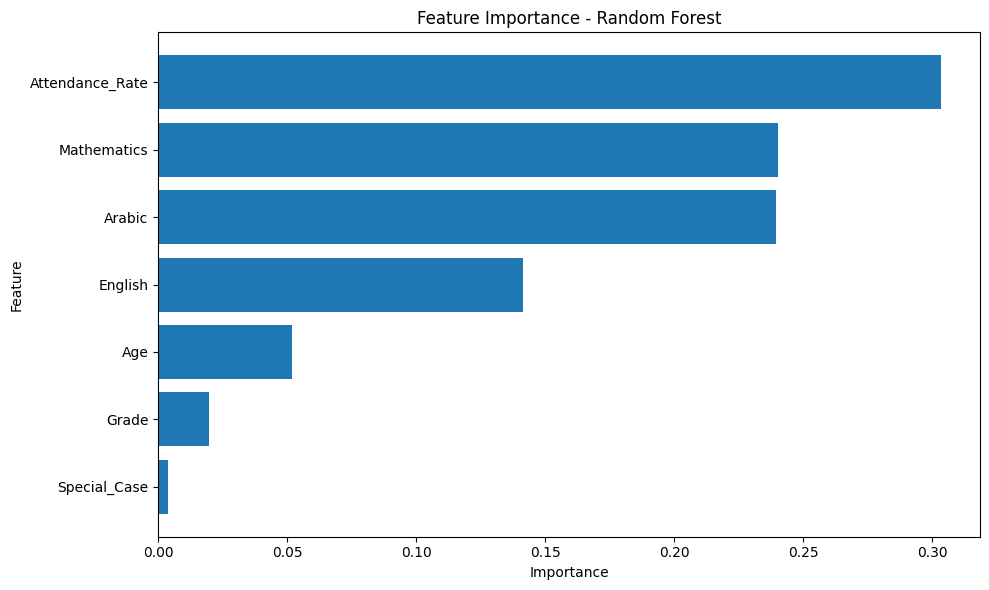

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename Arabic columns to English
feature_names_en = {
    'حالة خاصة': 'Special_Case',
    'الصف': 'Grade',
    'اللغة العربية': 'Arabic',
    'اللغة الإنجليزية': 'English',
    'الرياضيات': 'Mathematics'
}

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': [feature_names_en.get(col, col) for col in X.columns],
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display
print(feature_importance)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Feature importance analysis revealed that academic performance indicators and attendance-related features were the strongest predictors of at-risk students. Average score achieved the highest importance value, followed by attendance rate and absence frequency. In contrast, demographic features such as age and grade level showed minimal influence on prediction performance. These findings highlight the critical role of academic engagement and attendance behavior in early student risk detection.

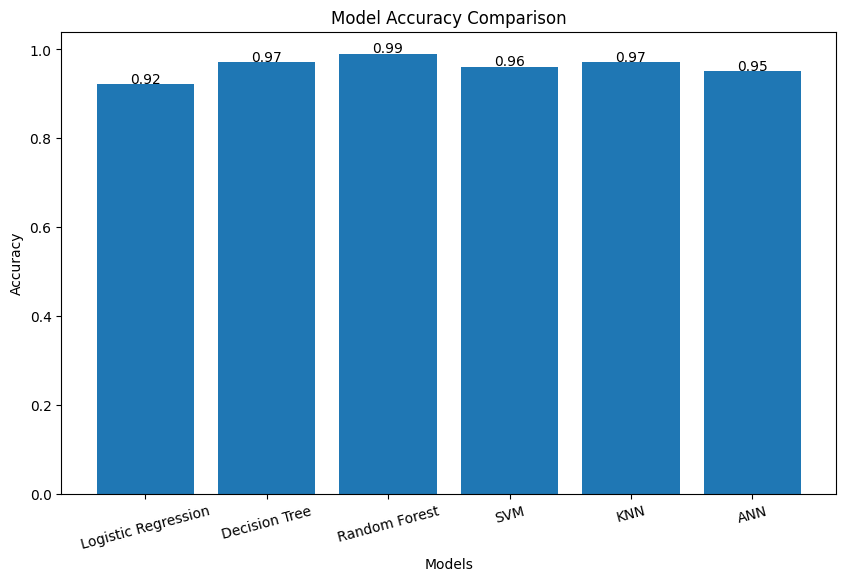

In [83]:
import matplotlib.pyplot as plt

# Model names
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'SVM',
    'KNN',
    'ANN'
]

# Accuracy values
accuracies = [
    log_accuracy,
    dt_accuracy,
    rf_accuracy,
    svm_accuracy,
    knn_accuracy,
    accuracy
]

# Create figure
plt.figure(figsize=(10,6))

# Bar plot
plt.bar(models, accuracies)

# Labels
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Rotate labels
plt.xticks(rotation=15)

# Show values on bars
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.002, f'{value:.2f}', ha='center')

# Show plot
plt.show()

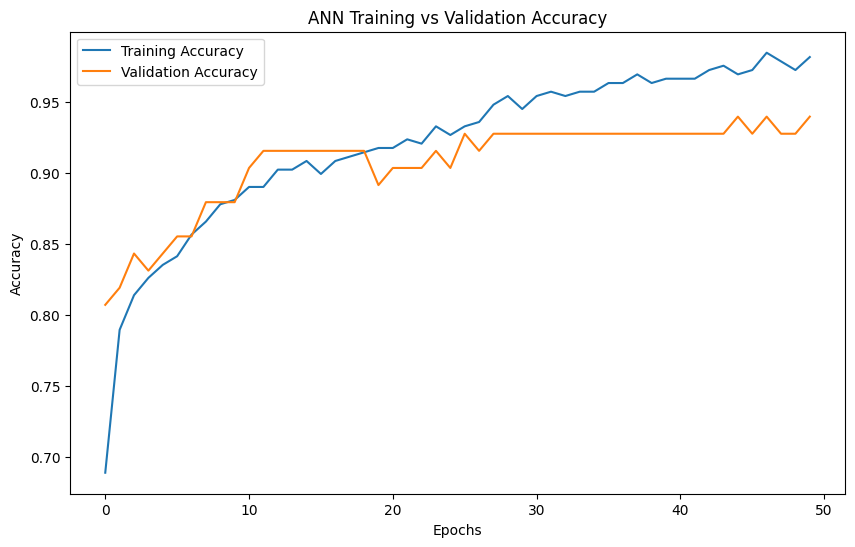

In [84]:
import matplotlib.pyplot as plt

# Plot training accuracy

plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Labels
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN Training vs Validation Accuracy')

# Legend
plt.legend()

# Show plot
plt.show()

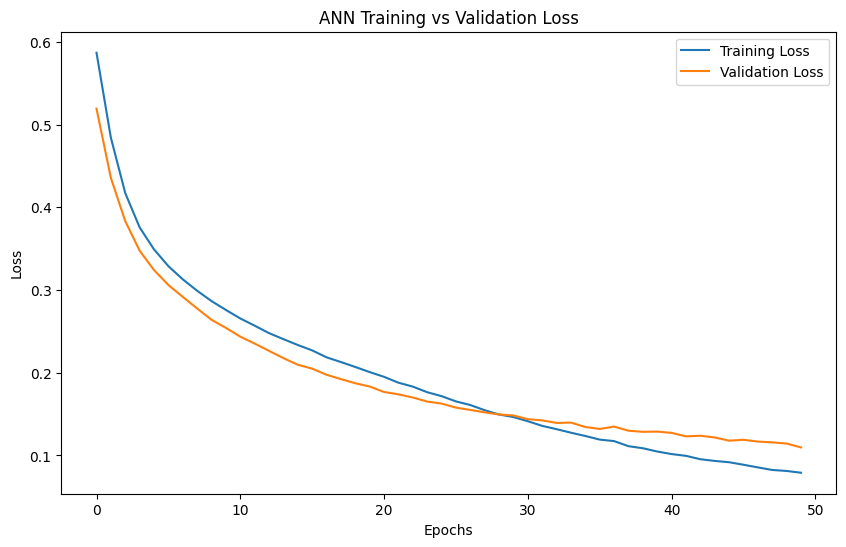

In [85]:
# Plot training loss

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Labels
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN Training vs Validation Loss')

# Legend
plt.legend()

# Show plot
plt.show()

 These curves demonstrate a consistent improvement in both training and validation accuracy, coupled with a steady decrease in loss over successive epochs. The close proximity of the training and validation curves suggests that the ANN model is learning effectively without significant overfitting, indicating good generalization capabilities to unseen data.

In [86]:
import pandas as pd

# Create comparison table

comparison_table = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'KNN',
        'ANN'
    ],

    'Test Accuracy': [
        round(log_accuracy, 3),
        round(dt_accuracy, 3),
        round(rf_accuracy, 3),
        round(svm_accuracy, 3),
        round(knn_accuracy, 3),
        round(accuracy, 3)
    ],

    'CV Accuracy': [
        round(cv_scores_log.mean(), 3),
        round(cv_scores_dt.mean(), 3),
        round(cv_scores_rf.mean(), 3),
        round(cv_scores_svm.mean(), 3),
        round(cv_scores_knn.mean(), 3),
        'N/A'
    ],

    'Complexity': [
        'Low',
        'Low',
        'Medium',
        'High',
        'Medium',
        'High'
    ],

    'Interpretability': [
        'High',
        'Very High',
        'Medium',
        'Low',
        'Low',
        'Very Low'
    ],

    'Overfitting Risk': [
        'Low',
        'High',
        'Low',
        'Medium',
        'Medium',
        'High'
    ]

})

# Display table
print(comparison_table)

                 Model  Test Accuracy CV Accuracy Complexity Interpretability  \
0  Logistic Regression          0.922       0.854        Low             High   
1        Decision Tree          0.971       0.963        Low        Very High   
2        Random Forest          0.990       0.981     Medium           Medium   
3                  SVM          0.961       0.899       High              Low   
4                  KNN          0.971       0.869     Medium              Low   
5                  ANN          0.951         N/A       High         Very Low   

  Overfitting Risk  
0              Low  
1             High  
2              Low  
3           Medium  
4           Medium  
5             High  


In [76]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Display AUC
print("AUC Score:", roc_auc)

AUC Score: 0.999047619047619


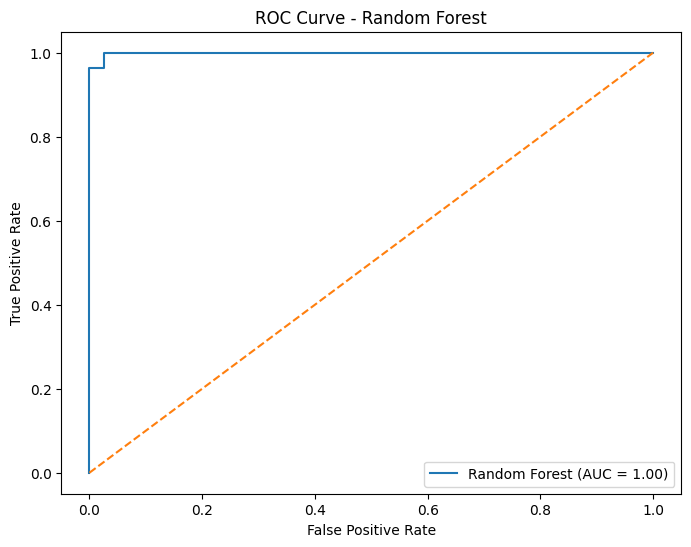

In [77]:
# Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.2f})'
)

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Title
plt.title('ROC Curve - Random Forest')

# Legend
plt.legend()

# Show plot
plt.show()

 The ROC curve analysis demonstrated excellent discriminative capability of the Random Forest model, achieving an AUC score of 0.999, which indicates highly accurate separation between at-risk and non-risk students.


--- ANN Evaluation ---
Test Accuracy: 0.9515


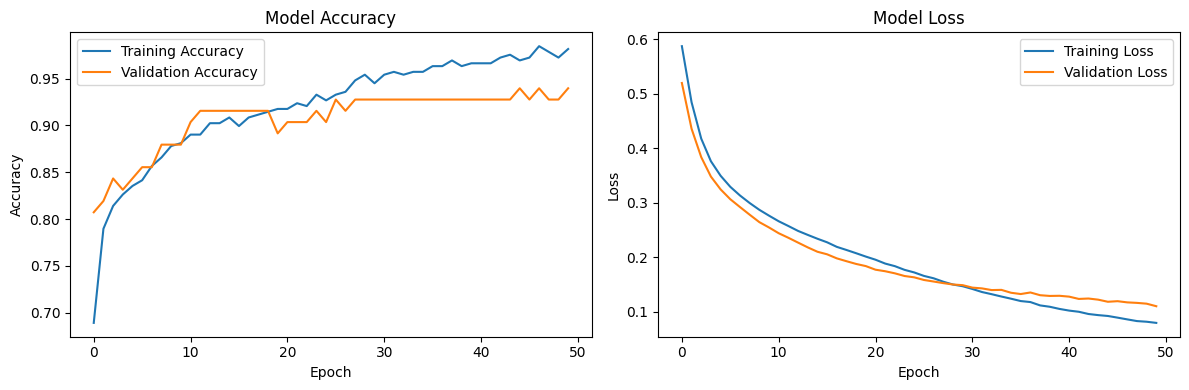

In [87]:
import matplotlib.pyplot as plt

# Model Evaluation
loss, accuracy = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n--- ANN Evaluation ---")
print(f"Test Accuracy: {accuracy:.4f}")

# (Accuracy Curve)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# (Loss Curve)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
